In [1]:
import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# feature_refinement.ipynb 실행 후 저장된 파일 로드
# (feature_refinement에서 저장 코드가 없으면 train_fe_v3.csv 로드 후
#  STEP1~3 직접 실행하거나, 아래처럼 fe_v3에서 바로 로드)
train = pd.read_csv('train_fe_v3.csv')
test  = pd.read_csv('test_fe_v3.csv')

TARGET = '임신 성공 여부'
ID_COL = 'ID'

print('Train:', train.shape, '/ Test:', test.shape)

Train: (256351, 192) / Test: (90067, 191)


In [2]:
# ── STEP 1: 중요도 0 피처 제거 ────────────────────────────────────
ZERO_IMP_COLS = [
    '배아생성_제로_플래그','배아생성_실패_플래그','난자수집_실패_플래그',
    '난자저장용_포함','배반포이식_여부','불임 원인 - 여성 요인',
    'IVF_배반포_조합','불임 원인 - 정자 면역학적 요인','high_resp_freezeall',
]
drop_cols = [c for c in ZERO_IMP_COLS if c in train.columns]
train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

# ── STEP 2~3: 교호작용 + 이식 배아 세분화 ────────────────────────
for df in [train, test]:
    emb_n   = df['이식된 배아 수'].fillna(0)
    emb_log = df['이식된 배아 수_log'].fillna(0)
    age     = df['나이_순서'].fillna(0)
    quality = df['배아품질_종합점수'].fillna(0)
    is_ivf  = (df['시술 유형'] == 'IVF').astype(int)
    is_tx   = df['이식배아_있음'].fillna(0)
    tx_day  = df['배아 이식 경과일'].replace(-1, np.nan).fillna(0)

    df['이식배아수_나이_교호']      = emb_n * age
    df['이식배아log_나이_교호']     = emb_log * age
    df['이식배아수_품질_교호']      = emb_n * quality
    df['이식배아log_품질_교호']     = emb_log * quality
    df['이식배아수_IVF_교호']       = emb_n * is_ivf
    df['이식성공_품질_교호']        = is_tx * quality
    df['고령자가난자_품질_교호']    = df['자가난자_고령_조합'].fillna(0) * quality
    df['고위험3중_이식배아_교호']   = df['고위험_3중_조합'].fillna(0) * emb_n
    df['이식경과일_이식배아_교호']  = tx_day * emb_n
    df['이식배아수_출산경험_교호']  = emb_n * df['출산경험_있음'].fillna(0)
    df['나이_저장비율_교호']        = age * df['저장_비율'].fillna(0)
    df['잔여배아_품질_교호']        = df['잔여배아_수'].fillna(0) * quality
    df['이식배아수_제곱']           = emb_n ** 2
    df['이식배아_총배아_곱']        = emb_n * df['총 생성 배아 수'].fillna(0)
    df['단일배아이식_여부']         = (emb_n == 1).astype(int)
    df['2개배아이식_여부']          = (emb_n == 2).astype(int)

print('피처 정제 + 교호작용 재적용 완료')
print('Train:', train.shape)

피처 정제 + 교호작용 재적용 완료
Train: (256351, 199)


In [3]:
# 피처 준비
feat_cols = [c for c in train.columns if c not in [TARGET, ID_COL]]

X      = train[feat_cols].copy()
y      = train[TARGET].copy()
X_test = test[feat_cols].copy()

# object와 string dtype 모두 범주형으로 잡기
cat_features = [
    c for c in feat_cols
    if X[c].dtype == 'object' or pd.api.types.is_string_dtype(X[c])
]

# 범주형 컬럼 명시적으로 object로 통일 (StringDtype → object)
for col in cat_features:
    X[col]      = X[col].astype(str).fillna('missing')
    X_test[col] = X_test[col].astype(str).fillna('missing')

# 인덱스 번호로 변환
cat_feature_indices = [X.columns.get_loc(c) for c in cat_features]

neg = (y == 0).sum()
pos = (y == 1).sum()
spw = neg / pos

print(f'피처: {len(feat_cols)}개')
print(f'범주형: {len(cat_features)}개 → {cat_features[:5]}...')
print(f'cat_feature_indices: {cat_feature_indices[:5]}...')
print(f'scale_pos_weight: {spw:.2f}')

피처: 197개
범주형: 21개 → ['시술 시기 코드', '시술 당시 나이', '시술 유형', '특정 시술 유형', '배란 유도 유형']...
cat_feature_indices: [0, 1, 3, 4, 6]...
scale_pos_weight: 2.87


In [4]:
# Optuna Objective 정의
# cat_features를 컬럼 인덱스(숫자)로 넘기는 방식 — 가장 확실한 해결책
# iloc 슬라이싱 + reset_index 조합으로도 간헐적 오류 발생 가능
# 인덱스 번호는 DataFrame 컬럼 순서 기반이므로 슬라이싱과 무관하게 안전
cat_feature_indices = [X.columns.get_loc(c) for c in cat_features]

def objective(trial):
    params = {
        'iterations':          trial.suggest_int('iterations', 300, 1000), 
        'learning_rate':       trial.suggest_float('learning_rate', 0.03, 0.3, log=True),
        'depth':               trial.suggest_int('depth', 4, 8),          
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':     trial.suggest_float('random_strength', 0.0, 5.0),  
        'border_count':        trial.suggest_int('border_count', 32, 128),  
        'loss_function':       'Logloss',
        'eval_metric':         'AUC',
        'scale_pos_weight':    spw,
        'random_seed':         42,
        'early_stopping_rounds': 50,
        'verbose':             False,
        'use_best_model':      True,
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    fold_aucs = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr  = X.iloc[tr_idx].reset_index(drop=True)
        X_val = X.iloc[val_idx].reset_index(drop=True)
        y_tr  = y.iloc[tr_idx].reset_index(drop=True)
        y_val = y.iloc[val_idx].reset_index(drop=True)

        train_pool = Pool(X_tr, y_tr, cat_features=cat_feature_indices)
        val_pool   = Pool(X_val, y_val, cat_features=cat_feature_indices)

        model = CatBoostClassifier(**params)
        model.fit(train_pool, eval_set=val_pool)

        val_pred = model.predict_proba(val_pool)[:, 1]
        fold_aucs.append(roc_auc_score(y_val, val_pred))

        trial.report(np.mean(fold_aucs), fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return np.mean(fold_aucs)

print('Objective 정의 완료')
print(f'cat_feature_indices: {cat_feature_indices[:5]}... (총 {len(cat_feature_indices)}개)')

Objective 정의 완료
cat_feature_indices: [0, 1, 3, 4, 6]... (총 21개)


In [5]:
# Optuna 탐색 실행
sampler = optuna.samplers.TPESampler(seed=42)
pruner  = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=pruner,
)

def print_callback(study, trial):
    print(f'Trial {trial.number:3d} | AUC: {trial.value:.5f} | Best: {study.best_value:.5f} | Params: depth={trial.params.get("depth")}, lr={trial.params.get("learning_rate"):.4f}, iter={trial.params.get("iterations")}')

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=False,   # ← False로 변경
    callbacks=[print_callback],
)


print(f'\n✅ 최적 AUC (3-fold): {study.best_value:.5f}')
print('최적 파라미터:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Trial   0 | AUC: 0.73864 | Best: 0.73864 | Params: depth=7, lr=0.2678, iter=562
Trial   1 | AUC: 0.73907 | Best: 0.73907 | Params: depth=7, lr=0.1197, iter=907
Trial   2 | AUC: 0.73961 | Best: 0.73961 | Params: depth=5, lr=0.0458, iter=427
Trial   3 | AUC: 0.73965 | Best: 0.73965 | Params: depth=5, lr=0.0588, iter=397
Trial   4 | AUC: 0.73979 | Best: 0.73979 | Params: depth=7, lr=0.0334, iter=715
Trial   5 | AUC: 0.73953 | Best: 0.73979 | Params: depth=4, lr=0.0605, iter=866
Trial   6 | AUC: 0.73936 | Best: 0.73979 | Params: depth=5, lr=0.2435, iter=324
Trial   7 | AUC: 0.73842 | Best: 0.73979 | Params: depth=7, lr=0.2797, iter=429
Trial   8 | AUC: 0.73902 | Best: 0.73979 | Params: depth=4, lr=0.0471, iter=362
Trial   9 | AUC: 0.73964 | Best: 0.73979 | Params: depth=6, lr=0.0573, iter=550
Trial  10 | AUC: 0.73962 | Best: 0.73979 | Params: depth=8, lr=0.0304, iter=747
Trial  11 | AUC: 0.73958 | Best: 0.73979 | Params: depth=6, lr=0.0937, iter=737
Trial  12 | AUC: 0.73961 | Best: 0.73979

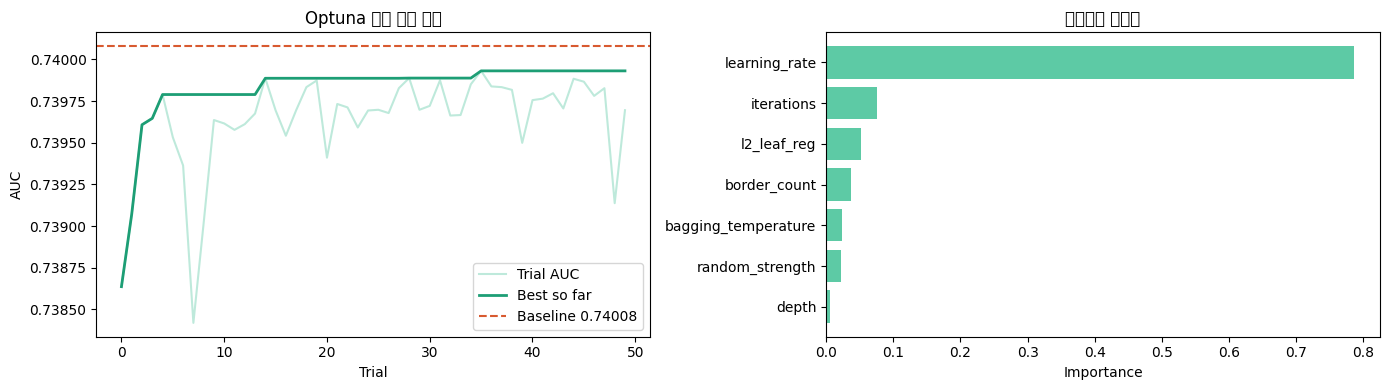

In [6]:
# Trial 히스토리 시각화
import matplotlib.pyplot as plt

trials_df = study.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# AUC 수렴 곡선
axes[0].plot(trials_df['number'], trials_df['value'], alpha=0.4, color='#5DCAA5', label='Trial AUC')
best_so_far = trials_df['value'].cummax()
axes[0].plot(trials_df['number'], best_so_far, color='#1D9E75', linewidth=2, label='Best so far')
axes[0].axhline(0.74008, color='#D85A30', linestyle='--', label='Baseline 0.74008')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('AUC')
axes[0].set_title('Optuna 탐색 수렴 곡선')
axes[0].legend()

# 파라미터 중요도
try:
    param_imp = optuna.importance.get_param_importances(study)
    axes[1].barh(list(param_imp.keys())[::-1], list(param_imp.values())[::-1], color='#5DCAA5')
    axes[1].set_title('파라미터 중요도')
    axes[1].set_xlabel('Importance')
except:
    axes[1].text(0.5, 0.5, 'trial 수 부족', ha='center', va='center')

plt.tight_layout()
plt.show()

In [7]:
# 최적 파라미터로 5-Fold 최종 학습
best_params = study.best_params
best_params.update({
    'loss_function':         'Logloss',
    'eval_metric':           'AUC',
    'scale_pos_weight':      spw,
    'random_seed':           42,
    'early_stopping_rounds': 30,
    'verbose':               False,
    'use_best_model':        True,
})

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_scores = []
models = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr  = X.iloc[tr_idx].reset_index(drop=True)
    X_val = X.iloc[val_idx].reset_index(drop=True)
    y_tr  = y.iloc[tr_idx].reset_index(drop=True)
    y_val = y.iloc[val_idx].reset_index(drop=True)

    train_pool = Pool(X_tr, y_tr, cat_features=cat_feature_indices)
    val_pool   = Pool(X_val, y_val, cat_features=cat_feature_indices)
    test_pool  = Pool(X_test, cat_features=cat_feature_indices)

    model = CatBoostClassifier(**best_params)
    model.fit(train_pool, eval_set=val_pool)

    val_pred = model.predict_proba(val_pool)[:, 1]
    fold_auc = roc_auc_score(y_val, val_pred)

    oof_preds[val_idx]  = val_pred
    test_preds         += model.predict_proba(test_pool)[:, 1] / N_SPLITS
    fold_scores.append(fold_auc)
    models.append(model)

    print(f'Fold {fold+1} | AUC: {fold_auc:.5f} | Best iter: {model.best_iteration_}')

oof_auc = roc_auc_score(y, oof_preds)
print(f'\n✅ OOF AUC (튜닝 후): {oof_auc:.5f}')
print(f'   Fold 평균: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}')
print(f'   베이스라인 대비: {oof_auc - 0.74008:+.5f}')

Fold 1 | AUC: 0.73831 | Best iter: 444
Fold 2 | AUC: 0.74320 | Best iter: 786
Fold 3 | AUC: 0.74083 | Best iter: 756
Fold 4 | AUC: 0.73832 | Best iter: 497
Fold 5 | AUC: 0.74070 | Best iter: 521

✅ OOF AUC (튜닝 후): 0.74026
   Fold 평균: 0.74027 ± 0.00183
   베이스라인 대비: +0.00018


In [11]:
# 제출 파일 저장
sample_sub = pd.read_csv('/Users/Jiyeon/Desktop/ftp/fertility-treatment-prediction/data/raw/sample_submission.csv')  

submission = sample_sub.copy()
submission[sample_sub.columns[1]] = test_preds  # 두 번째 컬럼에 예측값 덮어쓰기

submission.to_csv('submission_optuna.csv', index=False, encoding='utf-8-sig')
print('컬럼:', submission.columns.tolist())
print(submission.head())

print('저장 완료: submission_optuna.csv')
print(f'\nOOF AUC (튜닝 후) : {oof_auc:.5f}')
print(f'베이스라인         : 0.74008')
print(f'개선폭             : {oof_auc - 0.74008:+.5f}')
print(f'\n최적 파라미터:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

컬럼: ['ID', 'probability']
           ID  probability
0  TEST_00000     0.002918
1  TEST_00001     0.021377
2  TEST_00002     0.340401
3  TEST_00003     0.243083
4  TEST_00004     0.733241
저장 완료: submission_optuna.csv

OOF AUC (튜닝 후) : 0.74026
베이스라인         : 0.74008
개선폭             : +0.00018

최적 파라미터:
  iterations: 794
  learning_rate: 0.030094391673729362
  depth: 7
  l2_leaf_reg: 7.433949857398995
  bagging_temperature: 0.3980358270898108
  random_strength: 1.3075975210328405
  border_count: 108
